# Libraries

In [2]:
pip install pandas yfinance ta arch scikit-learn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 985.3/985.3 kB 15.3 MB/s eta 0:00:00
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=93ec24d452f99b1c1aa982ae852c7195376fb394ee4016ddc66b7a5b3255be83
  Stored in directory: /root/.cache/pip/wheels/a1/d7/29/7781cc5eb9a3659d032d7d15bdd0f49d07d2b24fec29f44bc4
Successfully built ta


# Data

In [15]:
import pandas as pd
import numpy as np
import yfinance as yf
from ta.volatility import AverageTrueRange
from ta.momentum import RSIIndicator
from arch import arch_model

# -----------------------------------
# STEP 1: Load price & VIX data
# -----------------------------------

# Example: S&P 500 and VIX
df_price = yf.download("^GSPC", start="2015-01-01")  # S&P 500
df_vix = yf.download("^VIX", start="2015-01-01")     # Implied VIX

# Keep necessary columns and align
df = df_price[['Close', 'High', 'Low']].copy()
df['VIX'] = df_vix['Close']

# Drop missing VIX values (e.g., holidays)
df.dropna(inplace=True)

# -----------------------------------
# STEP 2: Compute daily returns
# -----------------------------------
df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))
df['return'] = df['Close'].pct_change()

# -----------------------------------
# STEP 3: GARCH(1,1) volatility
# -----------------------------------
returns = df['log_return'].dropna() * 100  # scale for arch model
model = arch_model(returns, vol='GARCH', p=1, q=1)
res = model.fit(disp="off")
df.loc[returns.index, 'garch_vol'] = res.conditional_volatility

# -----------------------------------
# STEP 4: ATR (Average True Range)
# -----------------------------------
# # Ensure columns exist and no NaNs
# if df[['High', 'Low', 'Close']].isnull().values.any():
#     print("Warning: Missing values in High/Low/Close. Dropping them before ATR.")
#     df.dropna(subset=['High', 'Low', 'Close'], inplace=True)

# # Recompute ATR after dropping problematic rows
# atr = AverageTrueRange(high=df['High'], low=df['Low'], close=df['Close'], window=14)
# df['ATR'] = atr.average_true_range()


# -----------------------------------
# STEP 5: RSI (Momentum feature)
# -----------------------------------
rsi = RSIIndicator(close=df['Close'].squeeze(), window=14)
df['RSI'] = rsi.rsi()

# -----------------------------------
# STEP 6: Lagged returns
# -----------------------------------
for i in range(1, 6):  # 5 lagged returns
    df[f'return_lag_{i}'] = df['return'].shift(i)

# -----------------------------------
# STEP 7: Target — 5-day realized volatility (rolling std dev of returns)
# -----------------------------------
df['realized_vol_5d'] = df['return'].rolling(window=5).std()

# -----------------------------------
# STEP 8: Final cleanup
# -----------------------------------
df.dropna(inplace=True)

# -----------------------------------
# Final feature matrix & target
# -----------------------------------
features = ['return'] + [f'return_lag_{i}' for i in range(1, 6)] + [
    'garch_vol', 'VIX', 'RSI'
]
target = ['realized_vol_5d']

main = df[features+target]
X = df[features]
y = df[target]

print(X.head())
print(y.head())


/tmp/ipython-input-15-1614654591.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_price = yf.download("^GSPC", start="2015-01-01")  # S&P 500
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-15-1614654591.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_vix = yf.download("^VIX", start="2015-01-01")     # Implied VIX
[*********************100%***********************]  1 of 1 completed


Price         return return_lag_1 return_lag_2 return_lag_3 return_lag_4  \
Ticker                                                                     
Date                                                                       
2015-01-22  0.015270     0.004732     0.001550     0.013424    -0.009248   
2015-01-23 -0.005492     0.015270     0.004732     0.001550     0.013424   
2015-01-26  0.002568    -0.005492     0.015270     0.004732     0.001550   
2015-01-27 -0.013388     0.002568    -0.005492     0.015270     0.004732   
2015-01-28 -0.013496    -0.013388     0.002568    -0.005492     0.015270   

Price      return_lag_5 garch_vol        VIX        RSI  
Ticker                                                   
Date                                                     
2015-01-22    -0.005813  0.902660  16.400000  57.904317  
2015-01-23    -0.009248  1.025749  16.660000  53.845710  
2015-01-26     0.013424  0.971670  15.520000  55.411252  
2015-01-27     0.001550  0.890511  17.21999

In [8]:
X.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2640 entries, 2015-01-22 to 2025-07-22
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   (return, )        2640 non-null   float64
 1   (return_lag_1, )  2640 non-null   float64
 2   (return_lag_2, )  2640 non-null   float64
 3   (return_lag_3, )  2640 non-null   float64
 4   (return_lag_4, )  2640 non-null   float64
 5   (return_lag_5, )  2640 non-null   float64
 6   (garch_vol, )     2640 non-null   float64
 7   (VIX, )           2640 non-null   float64
 8   (RSI, )           2640 non-null   float64
dtypes: float64(9)
memory usage: 206.2 KB


In [9]:
X.isnull().sum()

,,0
Price,Ticker,
return,,0
return_lag_1,,0
return_lag_2,,0
return_lag_3,,0
return_lag_4,,0
return_lag_5,,0
garch_vol,,0
VIX,,0
RSI,,0


In [12]:
X.describe()

Price,return,return_lag_1,return_lag_2,return_lag_3,return_lag_4,return_lag_5,garch_vol,VIX,RSI
Ticker,,,,,,,,,
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,0.000495,0.000496,0.000496,0.000502,0.000496,0.000493,0.983866,18.386697,55.573572
std,0.011431,0.011431,0.011431,0.011434,0.011435,0.011436,0.596513,7.272456,11.408941
min,-0.119841,-0.119841,-0.119841,-0.119841,-0.119841,-0.119841,0.443231,9.140000,16.766413
25%,-0.003781,-0.003781,-0.003781,-0.003781,-0.003789,-0.003799,0.643815,13.447500,47.424279
50%,0.000691,0.000698,0.000698,0.000703,0.000698,0.000691,0.821600,16.520000,57.059201
75%,0.005804,0.005804,0.005804,0.005809,0.005809,0.005809,1.139025,21.405000,63.987569
max,0.095154,0.095154,0.095154,0.095154,0.095154,0.095154,7.844649,82.690002,86.686650


In [13]:
X.corr()

,Price,return,return_lag_1,return_lag_2,return_lag_3,return_lag_4,return_lag_5,garch_vol,VIX,RSI
,Ticker,,,,,,,,,
Price,Ticker,,,,,,,,,
return,,1.000000,-0.136289,0.081343,-0.034629,-0.069792,0.043143,0.008747,-0.159469,0.296809
return_lag_1,,-0.136289,1.000000,-0.136273,0.081480,-0.034746,-0.069866,-0.050241,-0.115973,0.258300
return_lag_2,,0.081343,-0.136273,1.000000,-0.136199,0.081429,-0.034770,-0.070568,-0.121165,0.243758
return_lag_3,,-0.034629,0.081480,-0.136199,1.000000,-0.136508,0.081174,-0.096159,-0.118962,0.218624
return_lag_4,,-0.069792,-0.034746,0.081429,-0.136508,1.000000,-0.136348,-0.110775,-0.104113,0.189182
return_lag_5,,0.043143,-0.069866,-0.034770,0.081174,-0.136348,1.000000,-0.131553,-0.108149,0.173824
garch_vol,,0.008747,-0.050241,-0.070568,-0.096159,-0.110775,-0.131553,1.000000,0.851026,-0.464105
VIX,,-0.159469,-0.115973,-0.121165,-0.118962,-0.104113,-0.108149,0.851026,1.000000,-0.535835


In [16]:
main.corr()

,Price,return,return_lag_1,return_lag_2,return_lag_3,return_lag_4,return_lag_5,garch_vol,VIX,RSI,realized_vol_5d
,Ticker,,,,,,,,,,
Price,Ticker,,,,,,,,,,
return,,1.000000,-0.136289,0.081343,-0.034629,-0.069792,0.043143,0.008747,-0.159469,0.296809,-0.005090
return_lag_1,,-0.136289,1.000000,-0.136273,0.081480,-0.034746,-0.069866,-0.050241,-0.115973,0.258300,-0.050670
return_lag_2,,0.081343,-0.136273,1.000000,-0.136199,0.081429,-0.034770,-0.070568,-0.121165,0.243758,-0.094295
return_lag_3,,-0.034629,0.081480,-0.136199,1.000000,-0.136508,0.081174,-0.096159,-0.118962,0.218624,-0.127420
return_lag_4,,-0.069792,-0.034746,0.081429,-0.136508,1.000000,-0.136348,-0.110775,-0.104113,0.189182,-0.174303
return_lag_5,,0.043143,-0.069866,-0.034770,0.081174,-0.136348,1.000000,-0.131553,-0.108149,0.173824,-0.168826
garch_vol,,0.008747,-0.050241,-0.070568,-0.096159,-0.110775,-0.131553,1.000000,0.851026,-0.464105,0.923432
VIX,,-0.159469,-0.115973,-0.121165,-0.118962,-0.104113,-0.108149,0.851026,1.000000,-0.535835,0.808076


# XGB

In [17]:
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

In [19]:
from xgboost import XGBRegressor
model = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)
model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [21]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Squared Error: {mse:.6f}")
print(f"Mean Absolute Error: {mae:.6f}")


Mean Squared Error: 0.000007
Mean Absolute Error: 0.001511


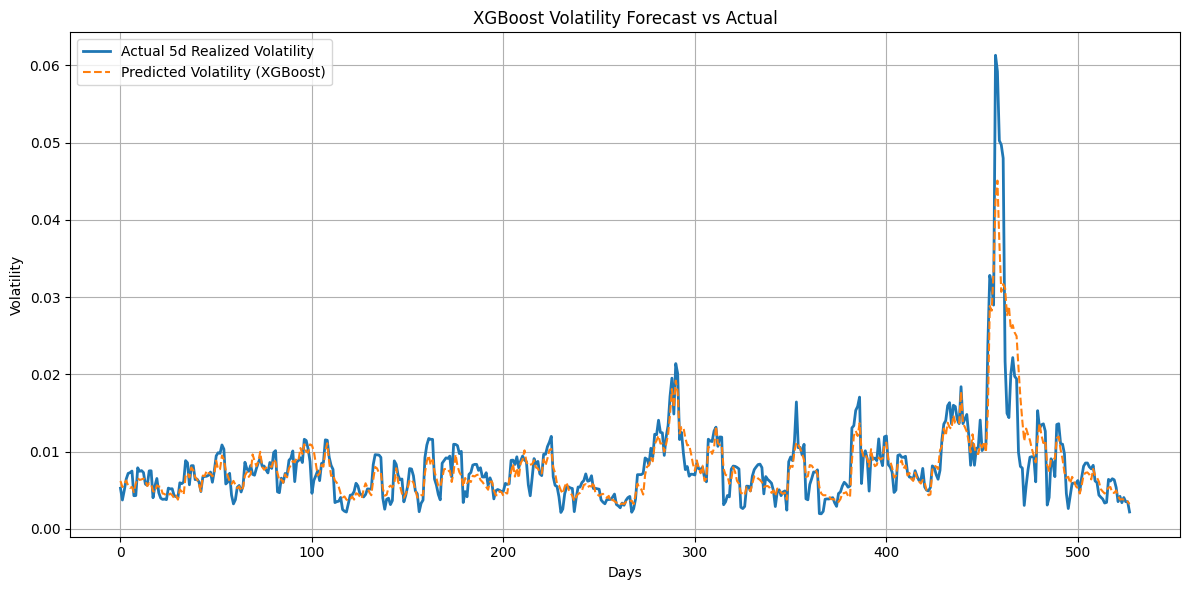

In [22]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual 5d Realized Volatility', linewidth=2)
plt.plot(y_pred, label='Predicted Volatility (XGBoost)', linestyle='--')
plt.title('XGBoost Volatility Forecast vs Actual')
plt.xlabel('Days')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
